# 第12章 结构健康监测中的机器学习算法

本Notebook提供了教材第12章核心机器学习算法的Python实现示例，主要用于模拟结构健康监测（SHM）中的损伤识别和状态分类任务。

## 目录
1. **聚类方法**：层次聚类、k-Means聚类
2. **树模型**：决策树、随机森林
3. **支持向量机**：线性可分SVM与非线性可分SVM（核函数）
4. **神经网络与深度学习**：MLP前馈网络、CNN卷积网络、LSTM时间序列预测
5. **集成学习对比**：XGBoost与决策树、随机森林、SVM的性能对比

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体与绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="SimHei")
import warnings
warnings.filterwarnings('ignore')

--- 
## 0. 生成模拟数据集
我们生成一个模拟的“结构损伤状态”二维数据集，包含3个类别（健康、轻度损伤、重度损伤），用于后续分类算法演示。

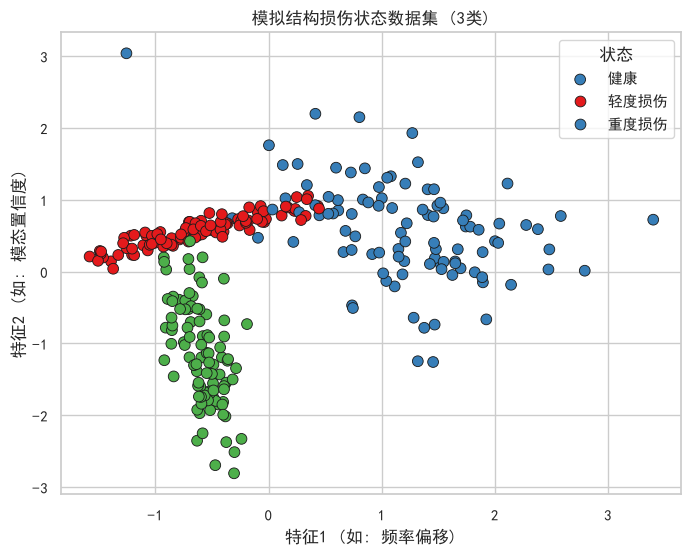

In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 生成分类数据集 (300个样本，2个特征便于可视化，3个类别)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, n_classes=3, random_state=42)

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette='Set1', s=60, edgecolor='k')
plt.title('模拟结构损伤状态数据集 (3类)')
plt.xlabel('特征1 (如: 频率偏移)')
plt.ylabel('特征2 (如: 模态置信度)')
plt.legend(title='状态', labels=['健康', '轻度损伤', '重度损伤'])
plt.show()

--- 
## 1. 聚类方法 (无监督学习)
### 1.1 层次聚类 (Hierarchical Clustering)

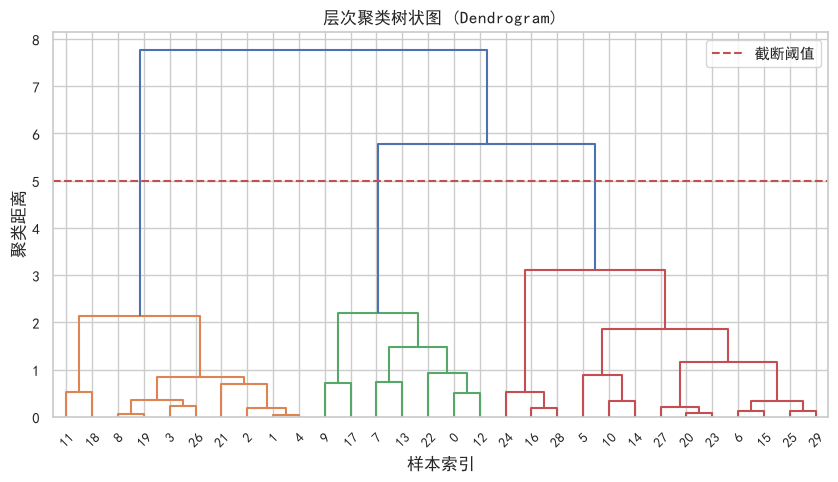

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 提取部分数据用于绘制树状图，以保持清晰
X_subset = X_scaled[:30]

plt.figure(figsize=(10, 5))
# 使用ward距离计算链接矩阵
Z = linkage(X_subset, method='ward')
dendrogram(Z)
plt.title('层次聚类树状图 (Dendrogram)')
plt.xlabel('样本索引')
plt.ylabel('聚类距离')
plt.axhline(y=5, color='r', linestyle='--', label='截断阈值')
plt.legend()
plt.show()

### 1.2 k-Means聚类

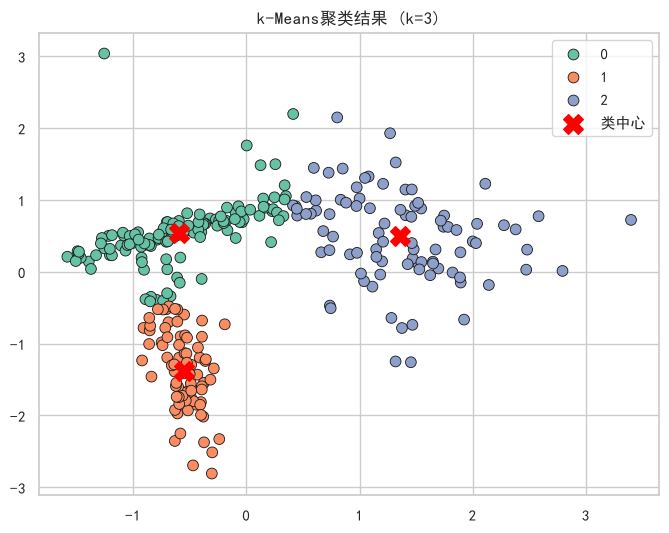

In [13]:
from sklearn.cluster import KMeans

# 设定k=3进行聚类
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_kmeans, palette='Set2', s=60, edgecolor='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='类中心')
plt.title('k-Means聚类结果 (k=3)')
plt.legend()
plt.show()

--- 
## 2. 树模型 (有监督学习)
### 2.1 决策树 (Decision Tree)

决策树测试集准确率: 0.9000


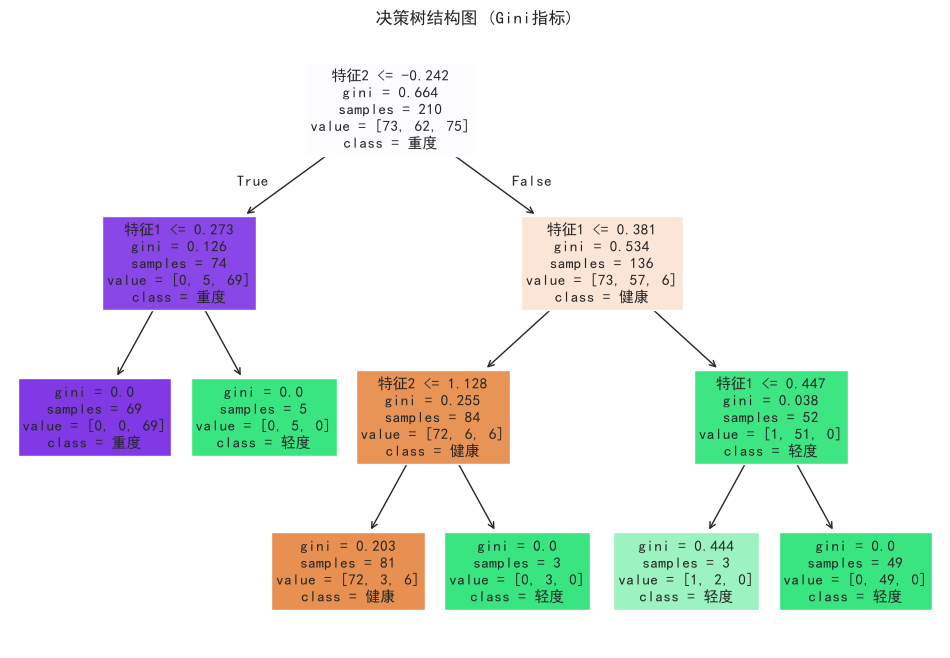

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"决策树测试集准确率: {accuracy_score(y_test, y_pred_dt):.4f}")

plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=['特征1', '特征2'], class_names=['健康', '轻度', '重度'])
plt.title('决策树结构图 (Gini指标)')
plt.show()

### 2.2 随机森林 (Random Forest)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"随机森林测试集准确率: {accuracy_score(y_test, y_pred_rf):.4f}")

随机森林测试集准确率: 0.9000


--- 
## 3. 支持向量机 (SVM)
绘制决策边界函数：

In [16]:
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', edgecolor='k')
    plt.title(title)
    plt.show()

### 3.1 线性SVM与非线性SVM(RBF核) 对比

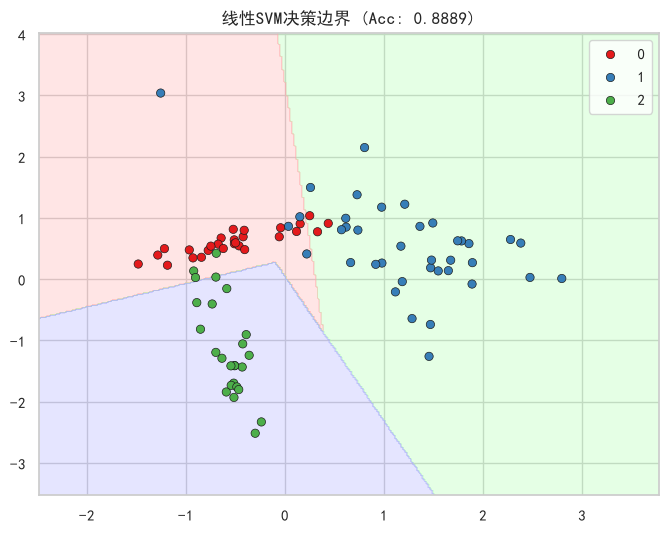

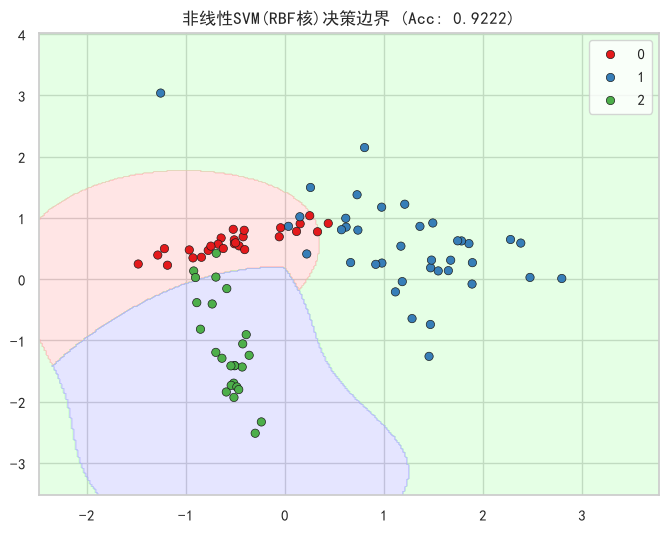

In [17]:
# 线性SVM
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
plot_decision_boundary(svm_linear, X_test, y_test, f'线性SVM决策边界 (Acc: {accuracy_score(y_test, svm_linear.predict(X_test)):.4f})')

# 非线性SVM (高斯核 RBF)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
plot_decision_boundary(svm_rbf, X_test, y_test, f'非线性SVM(RBF核)决策边界 (Acc: {accuracy_score(y_test, svm_rbf.predict(X_test)):.4f})')

--- 
## 4. 神经网络与深度学习
### 4.1 神经元与前馈神经网络 (MLP)

MLP神经网络测试集准确率: 0.9111


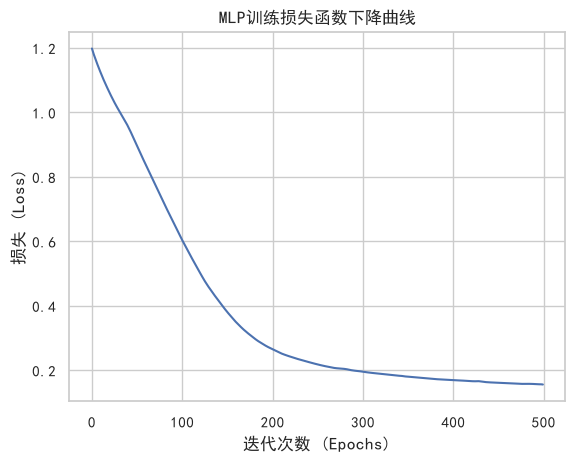

In [18]:
from sklearn.neural_network import MLPClassifier

# 使用ReLU激活函数的两层隐藏层网络
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print(f"MLP神经网络测试集准确率: {accuracy_score(y_test, y_pred_mlp):.4f}")

plt.plot(mlp.loss_curve_)
plt.title('MLP训练损失函数下降曲线')
plt.xlabel('迭代次数 (Epochs)')
plt.ylabel('损失 (Loss)')
plt.show()

### 4.2 深度学习: CNN与LSTM 示意 (基于PyTorch)
由于CNN通常处理图像，LSTM处理时间序列，这里构建两个极简的PyTorch模型结构，演示其网络层定义。

In [19]:
import torch
import torch.nn as nn

# 1. 卷积神经网络 (CNN) 结构定义
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 卷积层 -> 池化层 -> 卷积层 -> 池化层 -> 全连接层
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 3) # 假设输入为28x28图像
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # 展平
        x = self.fc(x)
        return x

# 2. 长短时记忆网络 (LSTM) 结构定义
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_classes=1):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)
        # 取最后一个时间步的输出
        out = self.fc(out[:, -1, :])
        return out

print("CNN网络结构:\n", SimpleCNN())
print("\nLSTM网络结构:\n", SimpleLSTM())

CNN网络结构:
 SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=1568, out_features=3, bias=True)
  (relu): ReLU()
)

LSTM网络结构:
 SimpleLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


--- 
## 5. XGBoost集成学习与各算法对比
在相同数据集下，对比决策树、随机森林、SVM和XGBoost的性能。

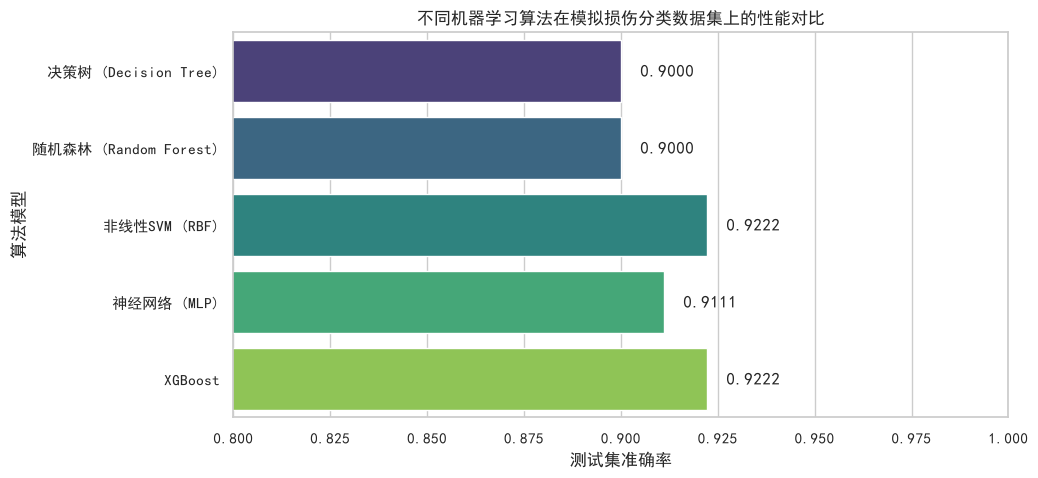

In [20]:
import xgboost as xgb

# 训练XGBoost模型
xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

# 汇总对比结果
results = {
    '算法模型': ['决策树 (Decision Tree)', '随机森林 (Random Forest)', '非线性SVM (RBF)', '神经网络 (MLP)', 'XGBoost'],
    '测试集准确率': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, svm_rbf.predict(X_test)),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
sns.barplot(x='测试集准确率', y='算法模型', data=df_results, palette='viridis')
plt.title('不同机器学习算法在模拟损伤分类数据集上的性能对比')
plt.xlim(0.8, 1.0)
for i, v in enumerate(df_results['测试集准确率']):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center')
plt.show()